In [429]:
import numpy as np 
import matplotlib.pyplot as plt 
import pymc
import cronos 

In [430]:
IVPDAG = pymc.FFGraph()

N_STAGE = 5

#States 
X_list = [pymc.FFVar(IVPDAG, f"X{i+1}") for i in range(N_STAGE)] #biomass concentration
A_list = [pymc.FFVar(IVPDAG, f"A{i+1}") for i in range(N_STAGE)] #active photosynthesis  
B_list = [pymc.FFVar(IVPDAG, f"B{i+1}") for i in range(N_STAGE)] #occupied phoyosynthesis
C_list = [pymc.FFVar(IVPDAG, f"C{i+1}") for i in range(N_STAGE)] #damaged photosynthesis 
alpha_list = [pymc.FFVar(IVPDAG, f"alpha{i+1}") for i in range(N_STAGE)] #acclimation rate 
Ig_list = [pymc.FFVar(IVPDAG, f"G{i+1}") for i in range(N_STAGE)] #acclimation irradiance 
Xd_list = [pymc.FFVar(IVPDAG, f"Xd{i+1}") for i in range(N_STAGE)] #dormant biomass concentration
X_s = pymc.FFVar(IVPDAG, "X_s")  #biomass concentration in storage tank 
X_ds = pymc.FFVar(IVPDAG, "X_d")  #dead biomass conc. in storage tank
A_s = pymc.FFVar(IVPDAG, "A_s")  #active photosynthesis in storage tank
B_s = pymc.FFVar(IVPDAG, "B_s")  #ocupied PSII in storage tank
C_s = pymc.FFVar(IVPDAG, "C_s")  #damaged PSII in storage tank

#Controls
v_net = pymc.FFVar(IVPDAG, "v_net") #net velocity 
I0 = pymc.FFVar(IVPDAG, "I0") #single incident light for all stages
D = pymc.FFVar(IVPDAG, "D") #dilution rate 
#Q_drop = pymc.FFVar(IVPDAG, "Q_gas") #droplet volumetric flowrate 

#initial concentrations 
X0 = pymc.FFVar(IVPDAG, "X0") # feed biomass to stage 1
A0 = pymc.FFVar(IVPDAG, "A0")
B0 = pymc.FFVar(IVPDAG, "B0")
C0 = pymc.FFVar(IVPDAG, "C0")
alpha0 = pymc.FFVar(IVPDAG, "alpha0")
Ig0 = pymc.FFVar(IVPDAG, "Ig0")  # initial acclimation irradiance
Xd0 = pymc.FFVar(IVPDAG, "Xd0")
X_s0 = pymc.FFVar(IVPDAG, "X_s0")
X_ds0 = pymc.FFVar(IVPDAG, "X_ds0")
A_s0 = pymc.FFVar(IVPDAG, "A_s0")
B_s0 = pymc.FFVar(IVPDAG, "B_s0")
C_s0 = pymc.FFVar(IVPDAG, "C_s0")

#parameters 

kr = pymc.FFVar(IVPDAG, "kr") #repair rate
kd = pymc.FFVar(IVPDAG, "kd") #damage rate
Res = pymc.FFVar(IVPDAG, "R") #Respiration rate 
tau = pymc.FFVar(IVPDAG, "tau") #turnover rate
xi = pymc.FFVar(IVPDAG, "xi") #NPQ rate 
n_h = pymc.FFVar(IVPDAG, "n_h") #HII component 
eta_P = pymc.FFVar(IVPDAG, "eta_P") #photoproduction 
eta_D = pymc.FFVar(IVPDAG, "eta_D") #thermal decay 
eta_qE = pymc.FFVar(IVPDAG, "eta_qE") #qE-quenching 
eta_I = pymc.FFVar(IVPDAG, "eta_I") #qI-quenching
nu = pymc.FFVar(IVPDAG, "nu") #stochiometry 
rho = pymc.FFVar(IVPDAG, "rho") #acclimation rate 
k_chi = pymc.FFVar(IVPDAG, "k_chi") #chi component 
N_0 = pymc.FFVar(IVPDAG, "N_0") #reference RCII
I_qE0 = pymc.FFVar(IVPDAG, "I_qE0") #NPQ interceept 
base0 = pymc.FFVar(IVPDAG, "base0") # base σ
e = pymc.FFVar(IVPDAG, "e") #NPQ slope 
PS2 = pymc.FFVar(IVPDAG, "PS2") #effective cross-section of photosystem II
theta0 = pymc.FFVar(IVPDAG, "theta0") #chi quota 
delta = pymc.FFVar(IVPDAG, "delta") #acclimation rate parameter
lamb = pymc.FFVar(IVPDAG, "lambda") #constant 


#constant
R_col = 0.5 #radius of droplet column
z = 2 #height of column 

In [431]:
def droplet_hydrodynamics(
    d_drop,          # droplet diameter [m]
    rho_water=1000,  # density of water [kg/m³]
    rho_air=1.2,     # density of air [kg/m³]
    mu_gas=1.8e-5,   # gas viscosity [Pa s]
    Q_gas=0.5e1,      # gas volumetric flowrate [m³/s]  <-- separate from liquid!
    R_col=0.5,      # column radius [m]
    dz=1
):
    g = 9.81
    v_term = (2*g*(rho_water-rho_air)*d_drop**2) / (9*mu_gas)

    A_col = np.pi * R_col**2
    u_gas = Q_gas / A_col      # realistic gas superficial velocity

    v_net = v_term - u_gas
    t_res = dz / v_net

    return v_net, t_res

def droplet_number_concentration(Q_drop, R_col, v_net, d_drop):
    A_col = np.pi * R_col**2
    V_column_per_s = A_col * v_net      # m³/s of reactor

    # droplet volume fraction in that stream
    phi_vol = Q_drop / V_column_per_s   # dimensionless

    # volume of ONE droplet
    V_drop = (4/3)*np.pi*(d_drop/2)**3

    # number of droplets per m³ of reactor
    n0 = phi_vol / V_drop
    return n0

# Example usage
d_drop = 80e-6 
Q_drop = 15e-5 # liquid volumetric flowrate
Q_gas  = 5e-3  # gas volumetric flowrate
R_col  = 0.5 #m
dz     = 0.5

v_net, t_res = droplet_hydrodynamics(d_drop, Q_gas=Q_gas, R_col=R_col, dz=dz)
n0 = droplet_number_concentration(Q_drop, R_col, v_net, d_drop)

print("v_net =", v_net)
print("t_res =", t_res)
print("n0 =", n0, "droplets/m³")


v_net = 0.7678147800541019
t_res = 0.6511987174364746
n0 = 927846911.7708167 droplets/m³


In [432]:
#z transition 
def z_transition(d0):
    return 12 * d0

def radius_profile(z, d0, r0, theta_initial):
    zt = z_transition(d0)
    r_transition = r0 + zt * np.tan(theta_initial)

    if np.isscalar(z):
        z_val = z
        if z_val < zt:
            return r0 + z_val * np.tan(theta_initial)
        else:
            return r_transition + (z_val - zt) * 0.1
            
    z = np.array(z)
    rz = np.zeros_like(z)

    # near-field
    mask_near = z < zt
    rz[mask_near] = r0 + z[mask_near] * np.tan(theta_initial)

    # far-field
    mask_far = ~mask_near
    rz[mask_far] = r_transition + (z[mask_far] - zt) * 0.1

    return rz

In [433]:
from scipy.special import spherical_jn, spherical_yn

def complex_refractive_index_droplet(theta_chl, X_gL, wavelength,
                                     a_chl_star,
                                     n_water=1.33,
                                     n_algae=1.39,
                                     rho_cell=1100.0): 
    """
    Computes complex refractive index of a water droplet containing microalgae.
    
    theta_chl : chlorophyll quota [g chl / g DW]
    X_gL      : biomass concentration in droplet [g DW / L]
    wavelength: wavelength [m]
    a_chl_star: chlorophyll-specific absorption [m^2/g chl]
    n_water   : refractive index of water
    n_algae   : refractive index of algal cytoplasm
    rho_cell  : cell density [kg/m^3]
    """

    # ---------- REAL PART (volume fraction mixing) ----------
    # Convert X from g/L → g/m3
    X_g_m3 = X_gL * 1000.0

    # Volume fraction of biomass in droplet
    f_vol = X_g_m3 / rho_cell
    n_eff = f_vol * n_algae + (1.0 - f_vol) * n_water

    # ---------- IMAG PART (absorption from chlorophyll) ----------
    # Chlorophyll concentration in droplet [g/L → g/m3]
    C_chl_m3 = theta_chl * X_gL * 1000.0

    # absorption coefficient a(λ)
    a_lambda = a_chl_star * C_chl_m3   # [1/m]
    k_eff = a_lambda * wavelength / (4.0 * np.pi)
    n_new = n_eff + 1j * k_eff
    return n_new

def mie_ab(m_rel, x, nmax):
    a = np.zeros(nmax, dtype=complex)
    b = np.zeros(nmax, dtype=complex)

    y = m_rel * x
    for n in range(1, nmax+1):
        jx   = spherical_jn(n, x)
        jx_p = spherical_jn(n, x, derivative=True)
        yx   = spherical_yn(n, x)
        yx_p = spherical_yn(n, x, derivative=True)
        hx   = jx + 1j*yx
        hx_p = jx_p + 1j*yx_p

        jy   = spherical_jn(n, y)
        jy_p = spherical_jn(n, y, derivative=True)

        a[n-1] = (m_rel*jy*jx_p - jx*jy_p) / (m_rel*jy*hx_p - hx*jy_p)
        b[n-1] = (jy*jx_p - m_rel*jx*jy_p) / (jy*hx_p - m_rel*hx*jy_p)

    return a, b

def mie_Qext(m_rel, r, wavelength):
    x = 2*np.pi*r / wavelength
    nmax = int(np.round(x + 4*x**(1/3) + 2))
    a, b = mie_ab(m_rel, x, nmax)
    n = np.arange(1, nmax+1)
    Q_ext = (2/x**2) * np.sum((2*n+1)*np.real(a + b))
    Q_sca = (2/x**2) * np.sum((2*n+1)*(np.abs(a)**2 + np.abs(b)**2))
    return Q_ext, Q_sca

def mie_coeff(d, wavelength, m_rel):
    r = d/2
    Q_ext, Q_sca = mie_Qext(m_rel, r, wavelength)
    C_ext = Q_ext * np.pi * r**2
    C_sca = Q_sca * np.pi * r**2
    return C_ext, C_sca

def number_droplet_z(n0, d_drop, z_height, r0, theta_initial):
    """
    Calculate droplet number concentration as function of height z
    n0: reference droplet concentration [droplets/m³]
    d_drop: droplet diameter [m]
    z_height: height in column [m]
    r0: initial spray radius [m]
    theta_initial: initial spray angle [rad]
    """
    r_drop = d_drop / 2
    rz = radius_profile(z_height, d_drop, r0, theta_initial)
    nz = n0 * (r_drop / rz)**2
    return nz


# Test: Compute C_ext for example parameters
if __name__ == "__main__":
    d_test = 80e-6          # droplet diameter [m]
    wavelength_test = 550e-9  # wavelength [m]
    theta_chl_test = 3.6    # chlorophyll quota [g chl / g DW]
    X_gL_test = 0.015       # biomass concentration [g/L]
    a_chl_star_test = 30  # chlorophyll-specific absorption [m²/g chl] - INCREASED for more absorption
    
    # Get complex refractive index
    n_complex = complex_refractive_index_droplet(
        theta_chl_test, X_gL_test, wavelength_test, a_chl_star_test
    )
    m_rel_test = n_complex / 1.33  # relative to water
    
    # Compute Mie coefficients
    C_ext, C_sca = mie_coeff(d_test, wavelength_test, m_rel_test)
    C_abs = C_ext - C_sca  # Absorption cross-section
    Beta = C_ext * 21233651 * d_test/2 * (X_s + X_ds)
    Sigma = C_sca * 21233651 * d_test/2 * (X_s + X_ds)
    
    print(f"Mie scattering cross-sections:")
    print(f"  Droplet diameter: {d_test*1e6:.1f} μm")
    print(f"  Wavelength: {wavelength_test*1e9:.0f} nm")
    print(f"  Biomass conc: {X_gL_test} g/L")
    print(f"  Chlorophyll quota: {theta_chl_test} g chl/g DW")
    print(f"  a_chl_star: {a_chl_star_test} m²/g chl")
    print(f"  C_ext = {C_ext:.6e} m²")
    print(f"  C_sca = {C_sca:.6e} m²")
    print(f"  C_abs = {C_abs:.6e} m²")
    print(f"  C_sca/C_ext ratio = {C_sca/C_ext:.3f}")
    #print(f"  Beta = {Beta:.6e}")
    #print(f"  Sigma = {Sigma:.6e}")
    #print(f"  Sigma/Beta ratio = {Sigma/Beta:.3f}")

Mie scattering cross-sections:
  Droplet diameter: 80.0 μm
  Wavelength: 550 nm
  Biomass conc: 0.015 g/L
  Chlorophyll quota: 3.6 g chl/g DW
  a_chl_star: 30 m²/g chl
  C_ext = 1.072263e-09 m²
  C_sca = 7.569704e-10 m²
  C_abs = 3.152929e-10 m²
  C_sca/C_ext ratio = 0.706


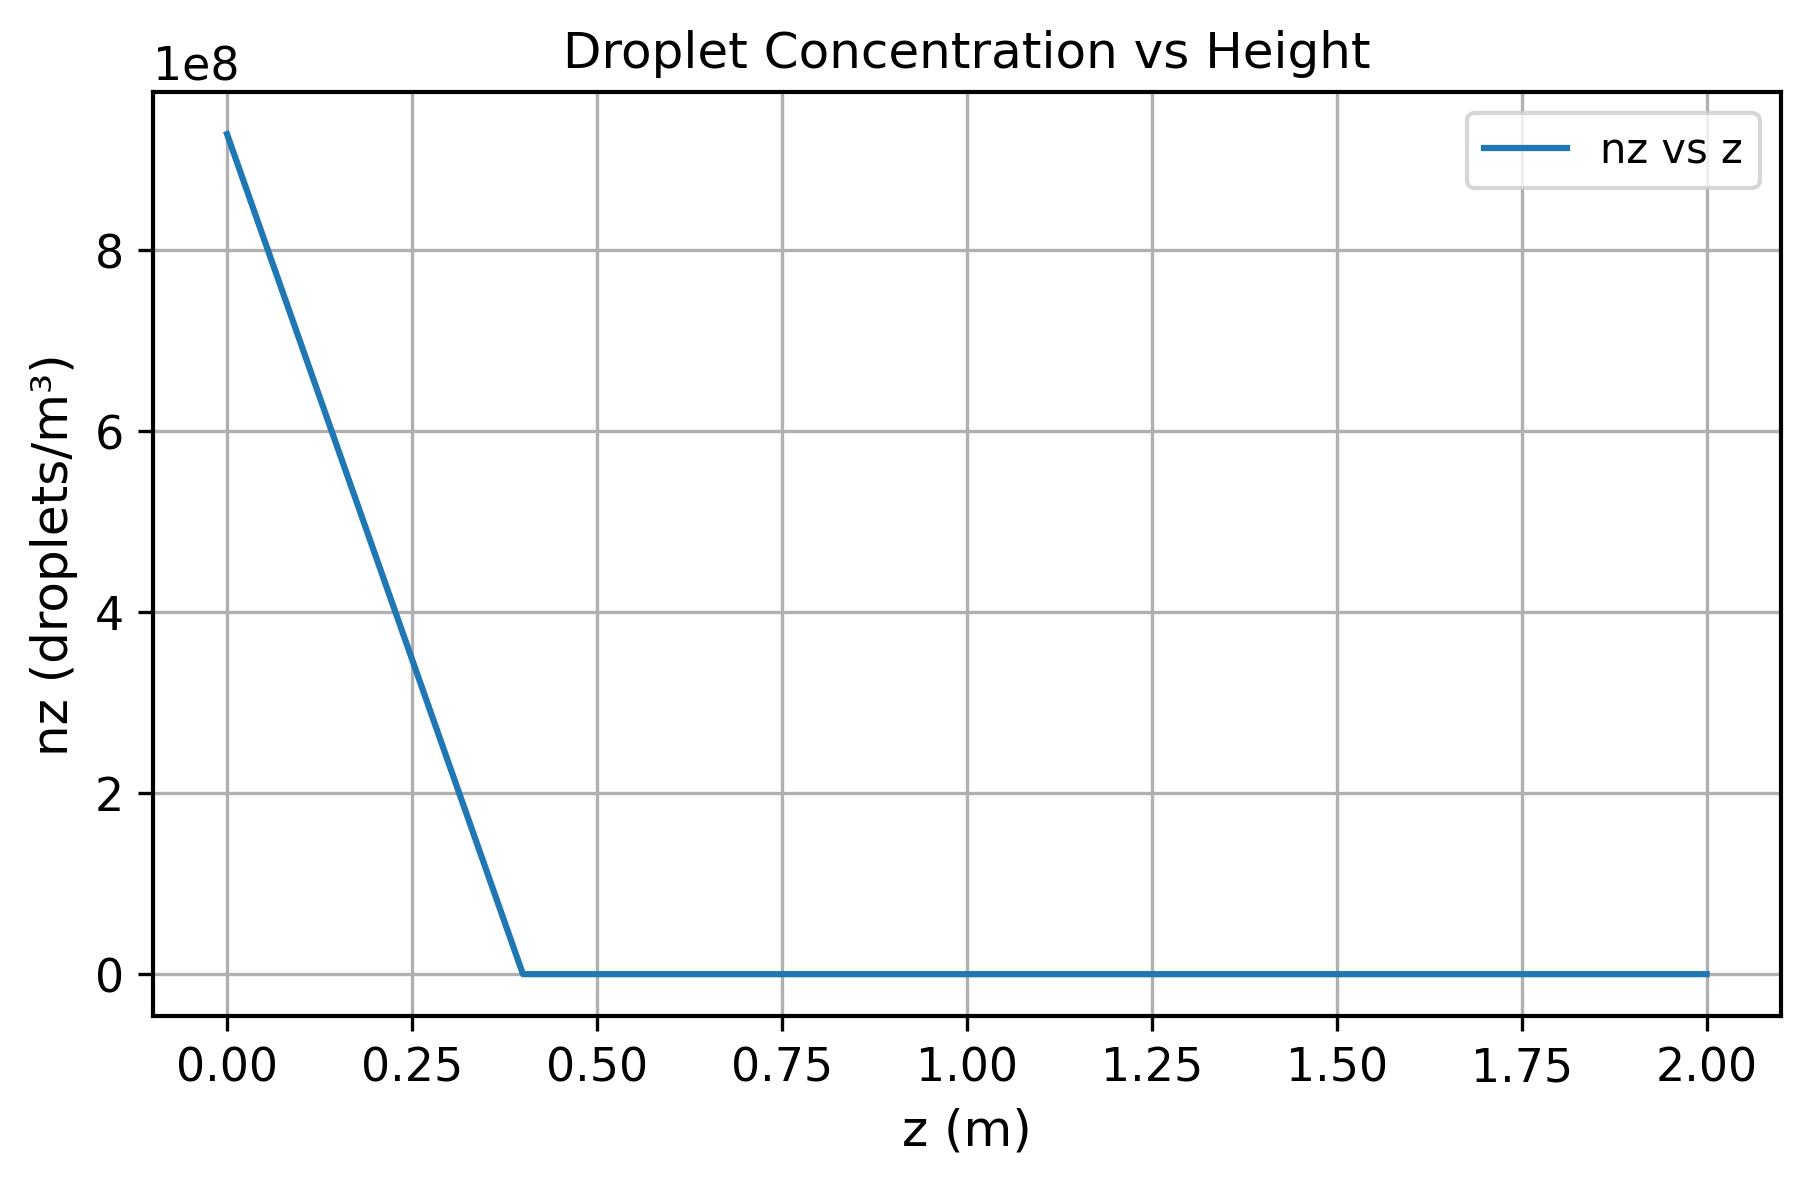

In [434]:
N_LAYERS = 5
z_total = 2
theta_initial = np.radians(5)
r_drop = d_drop / 2
r0 = r_drop  # or set to your initial spray radius

# Generate z values for each layer
z_values = np.linspace(0, z_total, N_LAYERS + 1)
nz_values = [number_droplet_z(n0, d_drop, z, r0, theta_initial) for z in z_values]

# Plot
plt.figure(figsize=(7, 4))
plt.plot(z_values, nz_values, label='nz vs z')
plt.xlabel('z (m)')
plt.ylabel('nz (droplets/m³)')
plt.title('Droplet Concentration vs Height')
plt.grid(True)
plt.legend()
plt.show()

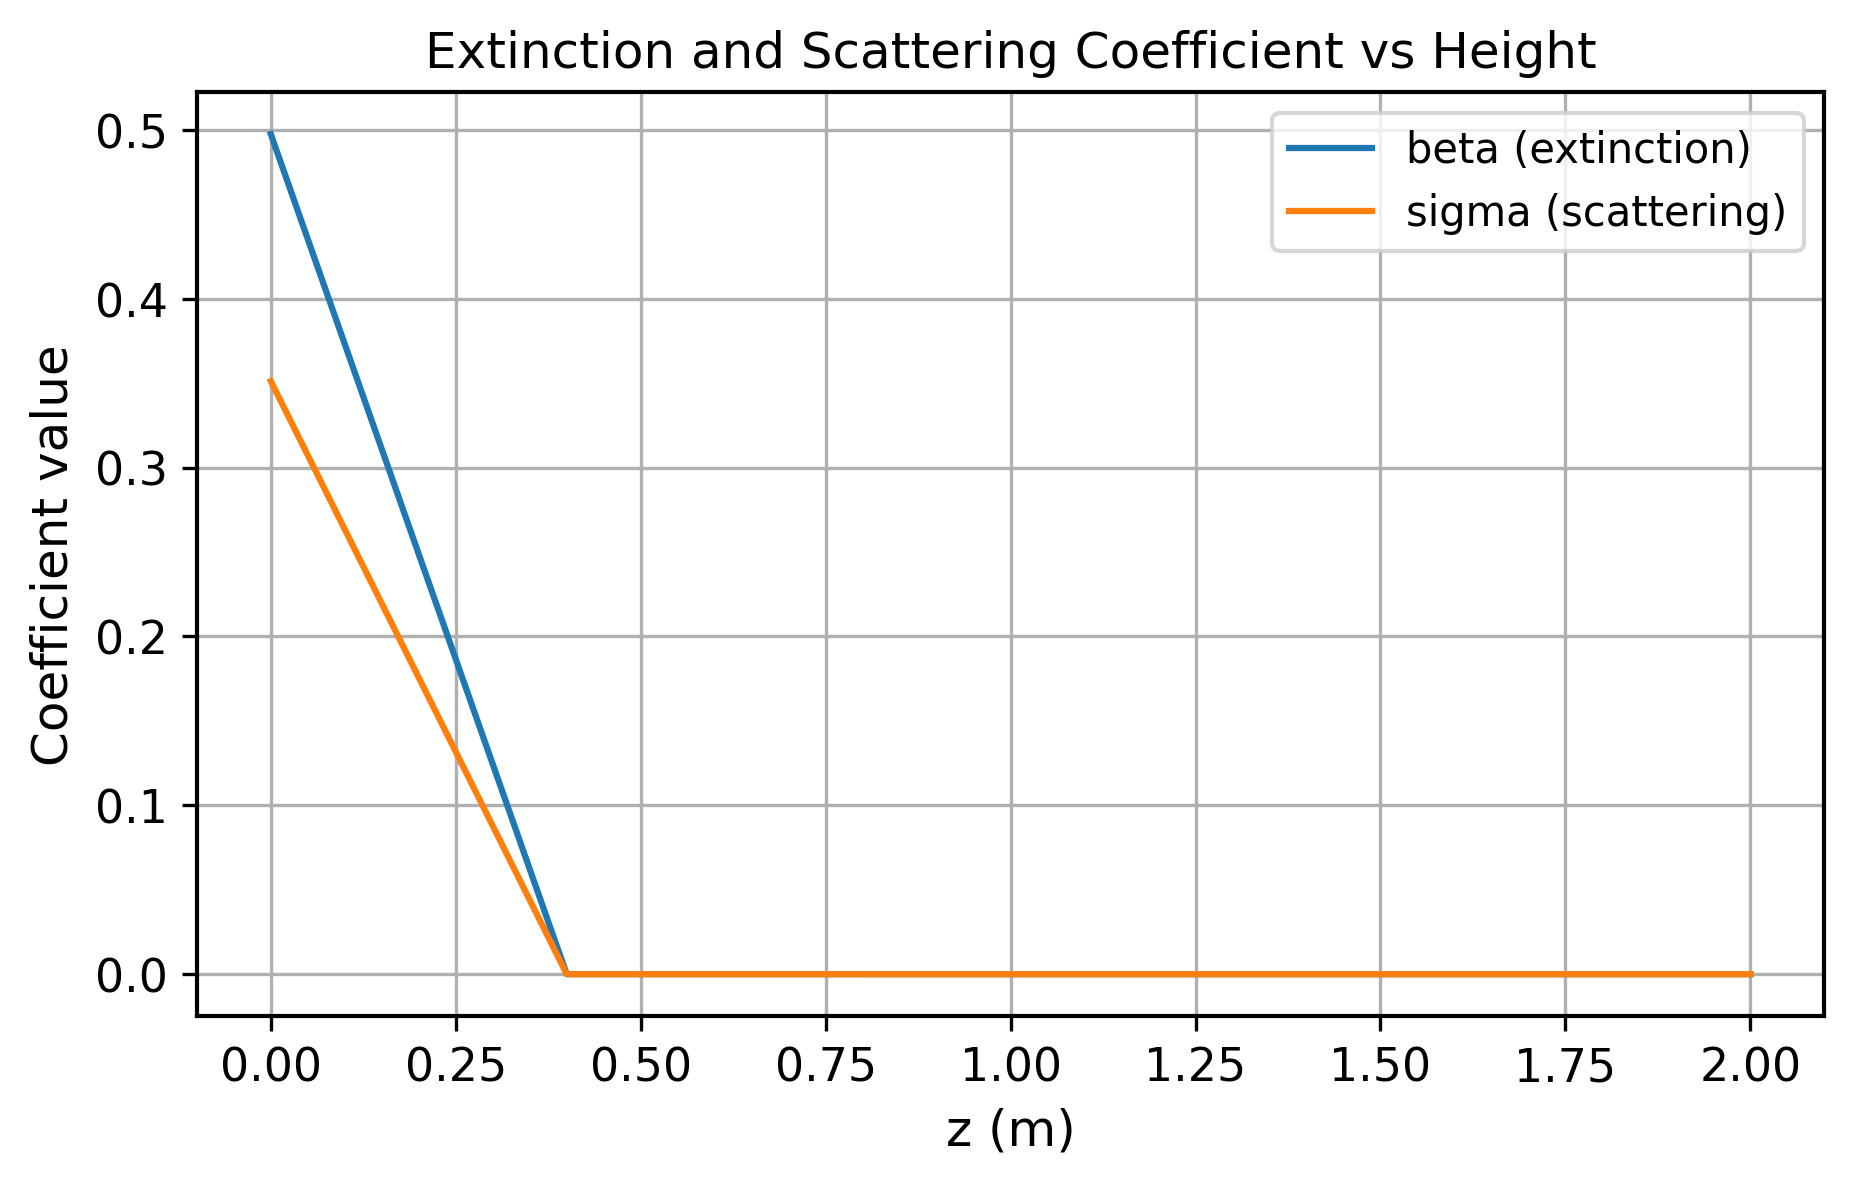

In [435]:
N_LAYERS = 5
z_total = 2
theta_initial = np.radians(10)
r_drop = d_drop / 2
r0 = r_drop  # or set to your initial spray radius

# Generate z values for each layer
z_values = np.linspace(0, z_total, N_LAYERS + 1)
nz_values = [number_droplet_z(n0, d_drop, z, r0, theta_initial) for z in z_values]

# Calculate beta and sigma for each z
beta_values = [C_ext * nz * R_col for nz in nz_values] 
sigma_values = [C_sca * nz * R_col for nz in nz_values] 

# Plot
plt.figure(figsize=(7, 4))
plt.plot(z_values, beta_values, label='beta (extinction)')
plt.plot(z_values, sigma_values, label='sigma (scattering)')
plt.xlabel('z (m)')
plt.ylabel('Coefficient value')
plt.title('Extinction and Scattering Coefficient vs Height')
plt.grid(True)
plt.legend()
plt.show()

In [436]:
dX_list = []
dA_list = []
dB_list = []
dC_list = []        
dIg_list = []
dalpha_list = []
dXd_list = []
mum_list = []
Ir_list = []  # Store final light intensity for each stage

# Constants 
b = 0.15
f = 1.0 - b
sqrt3 = pymc.sqrt(3)
K = 5  
dr = R_col / float(K)
X_fresh = 0.015
r_recycle = 0.8

#Vertical discretization 
N_LAYERS = 10
z = 2 
dz_layer = z / N_LAYERS
theta_initial = np.radians(10)
r_drop = d_drop / 2

# Constants for optical property calculation
d_drop_val = 80e-6   # Droplet diameter [m]
wavelength_val = 550e-9  # Wavelength [m]
a_chl_star_val = 2000  # Chlorophyll-specific absorption [m²/g chl]
theta_chl_ref = 3.6    # chlorophyll quota [g chl / g DW]
X_gL_ref = 0.015       # biomass concentration [g/L]

# Get complex refractive index (numerical computation)
n_complex_val = complex_refractive_index_droplet(
    theta_chl_ref, X_gL_ref, wavelength_val, a_chl_star_val
)
m_rel_val = n_complex_val / 1.33  # relative to water
C_ext, C_sca = mie_coeff(d_drop_val, wavelength_val, m_rel_val)
N_droplet = 1e10  # droplets per m³

# Loop over each stage
for i in range(N_STAGE):
    Ai = A_list[i]
    Bi = B_list[i]
    Ci = C_list[i]
    alphai = alpha_list[i]
    Igi = Ig_list[i]
    Xi = X_list[i]
    Xdi = Xd_list[i]
        
    # Boundary conditions 
    F_plus  = I0
    F_minus = 0.0
    
    integral_mu_r_total = 0.0

    for j in range(N_LAYERS):
        z_layer = (j + 0.5) * dz_layer
        nz_layer = number_droplet_z(n0, d_drop, z_layer, r_drop, theta_initial)
        beta_layer = float(np.real(C_ext * nz_layer)) * (Xi + Xdi)   # Extinction coefficient
        sigma_layer = float(np.real(C_sca * nz_layer)) * (Xi + Xdi)  # Scattering coefficient

        #Radial distribution 
        integral_mu_r_layer = 0.0

        for k in range(K + 1):
            r_k = k * dr
            
            # 1) Current local intensity at this radius [μmol/m²/s]
            Ir_k = (F_plus + F_minus)  # Keep in μmol/m²/s - no scaling!
            
            # Store final intensity for photosystem calculations
            if k == K:
                Ir_final = Ir_k

            # 2) compute local μ(r_k) for growth rate integration only
            thetai = (theta0 * Igi**k_chi) 
            Ni     = (N_0  * Igi**lamb )
            I_qEi  = I_qE0 + e * Igi
            denom = 1.0 + eta_D + eta_qE*alphai + Ai*eta_P + Ci*eta_I
            mu_ki  = (Ir_k * base0 * nu * (Ai * eta_P) / denom - Res) * thetai
            
            # 3) accumulate weighted integral ∫ μ(r) r dr with trapezoid weights
            if k == 0 or k == K:
                w = 1.0
            else:
                w = 2.0
                integral_mu_r_layer += w * mu_ki * r_k
                
            # Update fluxes using stage-specific optical properties
            if k < K:
                dF_plus  = sqrt3 * dr * (-beta_layer*(Xi + Xdi)*F_plus + sigma_layer*(f*F_plus + b*F_minus))
                dF_minus = sqrt3 * dr * ( beta_layer*(Xi + Xdi)*F_minus - sigma_layer*(f*F_minus + b*F_plus))
                F_plus   = F_plus  + dF_plus
                F_minus  = F_minus + dF_minus

        integral_mu_r_total += integral_mu_r_layer

    # radial average: μ̄ = 2 / R^2 ∫ μ(r) r dr
    mu_avgi = (2.0 / (R_col**2)) * integral_mu_r_total * dr / 2.0
    #mu_avg_1i = mu_avgi  # default if no limitation
    mu_max = 5.40e-5      # or whatever is physically reasonable
    eps_mu = 1e-12

    H = 0.5 * (1.0 + mu_avgi / pymc.sqrt(mu_avgi**2 + eps_mu))
    S = mu_max * (mu_avgi*2) / (mu_avgi + mu_max*2)

    mu_avg_1i = H * S
    
    # Photosystem dynamics
    sigma_PS2 = base0 * eta_P / (Ni * (1.0 + eta_D + eta_qE*alphai + eta_P))

    k_AB = Ir_k * sigma_PS2 * Ai
    k_BA = Bi / tau
    k_BC = kd * sigma_PS2 * Ir_k * Bi
    k_CB = kr * Ci

    #---------CSTR Mass Balances-------------
    if i == 0:
        #stage 1: feed from fresh + recycle from storage tank
          # Fresh feed concentration [g/L]

        X_in = X_fresh + r_recycle * X_s  # Use X_si (storage tank for this stage)
        Xd_in = r_recycle * X_ds
        A_in = (1.0 - r_recycle) * A0 + r_recycle * A_s
        B_in = (1.0 - r_recycle) * B0 + r_recycle * B_s
        C_in = (1.0 - r_recycle) * C0 + r_recycle * C_s
    else: 
        # Later stages: feed from previous stage
        X_in = X_list[i-1]
        Xd_in = Xd_list[i-1]
        A_in = A_list[i-1]
        B_in = B_list[i-1]
        C_in = C_list[i-1]

    dAi = -k_AB + k_BA + D * (A_in - Ai)
    dBi =  k_AB - k_BA + k_CB - k_BC + D * (B_in - Bi)
    dCi =  k_BC - k_CB + D * (C_in - Ci)

    NPQ_target = (Ir_k**n_h) / (I_qEi**n_h + Ir_k**n_h)
    #I_eff = (Ir_i**2)**0.5        # = |Ir_i|, smooth and differentiable
    #x = I_qEi**n_h
    #NPQ_target = x / (1.0 + x)
    dalphai = -xi * (alphai - NPQ_target)
    dIgi = delta * (Ir_k  - Igi ) * mu_avg_1i
  
    
    dXi = mu_avg_1i * Xi + D * (X_in - Xi)
    dXdi = Res * Xi + D * (Xd_in - Xdi)

    dX_list.append(dXi)
    dA_list.append(dAi)
    dB_list.append(dBi)
    dC_list.append(dCi)
    dalpha_list.append(dalphai)
    dIg_list.append(dIgi)
    dXd_list.append(dXdi)
    mum_list.append(mu_avg_1i)

# Storage tank equations (OUTSIDE loop - single shared tank receiving from last stage)
X_last  = X_list[N_STAGE-1]
Xd_last = Xd_list[N_STAGE-1]
A_last  = A_list[N_STAGE-1]
B_last = B_list[N_STAGE-1]
C_last  = C_list[N_STAGE-1]
alpha_last = alpha_list[N_STAGE-1]
Ig_last    = Ig_list[N_STAGE-1]

# Dark Storage Tank growth
sigma_PS2_dark = base0 * eta_P / (N_0 * Ig_last**lamb * (1.0 + eta_D + eta_qE*alpha_last + eta_P))
I_dark    = 0.0
thetalast = (theta0 * Ig_last**k_chi) 
denom_dark = 1.0 + eta_D + eta_qE*alpha_last + A_s*eta_P + C_s*eta_I
mu_dark   = (I_dark * base0 * nu * (A_s*eta_P) / denom_dark - Res) * thetalast

H_dark = 0.5 * (1.0 + mu_dark / pymc.sqrt(mu_dark**2 + eps_mu))
S_dark = mu_max * (mu_dark*2) / (mu_dark + mu_max*2)
mu_dark_1 = H_dark * S_dark

k_AB_dark = I_dark * sigma_PS2_dark * A_s
k_BA_dark = B_s / tau
k_BC_dark = kd * sigma_PS2_dark * I_dark * B_s
k_CB_dark = kr * C_s

dA_dark = -k_AB_dark + k_BA_dark + D * A_last - D * A_s
dB_dark = k_AB_dark - k_BA_dark + k_CB_dark - k_BC_dark + D * B_last - D * B_s
dC_dark = k_BC_dark - k_CB_dark + D * C_last - D * C_s

dX_s  = D * X_last - D * X_s  + mu_dark_1 * X_s
dX_ds = Res * X_s  - D * X_ds + D * Xd_last

P = 1/5 * (sum(mum_list) * X_s)
P = [mum_list, X_s] 

state_list = []
dstate_list = []
for i in range(N_STAGE):
    state_list   += [X_list[i], A_list[i], B_list[i], C_list[i], alpha_list[i], Ig_list[i], Xd_list[i]]
    dstate_list  += [dX_list[i], dA_list[i], dB_list[i], dC_list[i], dalpha_list[i], dIg_list[i], dXd_list[i]]

# Add storage tank states at the end
dstate_list += [dX_s, dX_ds, dA_dark, dB_dark, dC_dark]
state_list += [X_s, X_ds, A_s, B_s, C_s]

In [437]:
IVP = cronos.ODESLV()
IVP.set_dag(IVPDAG)

IVP.set_parameter([
    base0, kr, kd, Res, tau, xi, n_h, nu,
    eta_P, eta_D, eta_qE, eta_I, k_chi, e,
    N_0, I_qE0, theta0, delta, lamb
])
IVP.set_constant([I0, D, X0, A0, B0, C0, alpha0, Ig0, Xd0, X_s0, X_ds0, A_s0, B_s0, C_s0])
IVP.set_state(state_list)

timegrid = np.linspace(0, 86400 * 365, 51).tolist()  # 50 days in seconds
IVP.set_time(timegrid)

IVP.set_differential(dstate_list)

init = []
for _ in range(N_STAGE):
    init += [X0, A0, B0, C0, alpha0, Ig0, Xd0]  # 7 states per stage
init += [X_s0, X_ds0, A_s0, B_s0, C_s0]
IVP.set_initial(init)
Y = mum_list
F = []
for k in range(len(timegrid)):
    # For each time point k, map each Y[i] to a unique output index k*len(Y)+i
    F.append({k*len(Y) + i: Y[i] for i in range(len(Y))})

IVP.setup()

In [438]:
IVP.options.DISPLEVEL = 1     # display numerical integration results
IVP.options.RESRECORD = 50     # fewer output points = faster

# Solver tolerances - tightened for stability
IVP.options.LINSOL = IVP.options.DENSE
IVP.options.RTOL = 1e-4        # relative tolerance (tighter)
IVP.options.ATOL = 1e-6        # absolute tolerance (tighter)
IVP.options.HMAX  = 1000       # max step size [s]
IVP.options.HMIN  = 1e-20      # allow smaller steps for stiff regions
IVP.options.NMAX = 500000      # more steps allowed

param_vals = [
    # --- optical (1) ---
    1.75e0,       # 1  base0 [m²/μmol] 

    # --- kinetic rates (7) ---
    5.50e-5,       # 2  kr
    6.41e-7,       # 3  kd
    1.78e-5,        # 4  Res - death rate to balance growth at target
    5e-3,          # 5  tau
    5.95e-2,       # 6  xi
    2.26,          # 7  n_h
    4.0,           # 8  nu

    # --- photochemistry / quenching (6) ---
    1.14e1,        # 9  eta_P
    5.0e0,         # 10 eta_D
    1.98e1,        # 11 eta_qE
    7.87e1,        # 12 eta_I
    -1.89e-1,      # 13 k_chi
    4.48e-1,       # 14 e

    # --- acclimation / photoacclimation (6) ---
    1.71,          # 15 N_0
    813.0,         # 16 I_qE0 [μmol/m²/s]
    3.60,          # 17 theta0
    1.38e-1,       # 18 delta
    1.22e-1        # 19 lamb
]

const_vals = [
    180,      # I0 [μmol/m²/s]
    0.002480 ,   # D = 1.73 day⁻¹ - higher dilution to control growth
    0.015,     # X0 = 0.05 g/L (fresh feed at target concentration!)
    0.8,      # A0 (high active fraction)
    0.15,     # B0
    0.05,     # C0 (A+B+C=1)
    0.0,      # alpha0
    200.0,    # Ig0
    0.0,      # Xd0
    0.0,      # X_s0
    0.0,      # X_ds0
    1.0,      # A_s0
    0.0,      # B_s0
    0.0,
]

# Run the IVP
IVP.solve_state(param_vals, const_vals)

 @t = 0.000000e+00 :
  x[0] = 1.500000e-02
  x[1] = 8.000000e-01
  x[2] = 1.500000e-01
  x[3] = 5.000000e-02
  x[4] = 0.000000e+00
  x[5] = 2.000000e+02
  x[6] = 0.000000e+00
  x[7] = 1.500000e-02
  x[8] = 8.000000e-01
  x[9] = 1.500000e-01
  x[10] = 5.000000e-02
  x[11] = 0.000000e+00
  x[12] = 2.000000e+02
  x[13] = 0.000000e+00
  x[14] = 1.500000e-02
  x[15] = 8.000000e-01
  x[16] = 1.500000e-01
  x[17] = 5.000000e-02
  x[18] = 0.000000e+00
  x[19] = 2.000000e+02
  x[20] = 0.000000e+00
  x[21] = 1.500000e-02
  x[22] = 8.000000e-01
  x[23] = 1.500000e-01
  x[24] = 5.000000e-02
  x[25] = 0.000000e+00
  x[26] = 2.000000e+02
  x[27] = 0.000000e+00
  x[28] = 1.500000e-02
  x[29] = 8.000000e-01
  x[30] = 1.500000e-01
  x[31] = 5.000000e-02
  x[32] = 0.000000e+00
  x[33] = 2.000000e+02
  x[34] = 0.000000e+00
  x[35] = 0.000000e+00
  x[36] = 0.000000e+00
  x[37] = 1.000000e+00
  x[38] = 0.000000e+00
  x[39] = 0.000000e+00
 @t = 6.307200e+05 :
  x[0] = 3.707701e+00
  x[1] = 7.035355e-01
  x[

<Status.Normal: 0>

1.368038e+00
  x[7] = 7.256728e+00
  x[8] = 7.035602e-01
  x[9] = 2.171182e-01
  x[10] = 7.932163e-02
  x[11] = 2.555770e-02
  x[12] = 1.784602e+02
  x[13] = 1.419722e+00
  x[14] = 7.584923e+00
  x[15] = 7.024132e-01
  x[16] = 2.166078e-01
  x[17] = 8.097908e-02
  x[18] = 2.551286e-02
  x[19] = 1.783194e+02
  x[20] = 1.473747e+00
  x[21] = 7.927960e+00
  x[22] = 7.013123e-01
  x[23] = 2.160977e-01
  x[24] = 8.258998e-02
  x[25] = 2.546396e-02
  x[26] = 1.781658e+02
  x[27] = 1.530218e+00
  x[28] = 8.286511e+00
  x[29] = 7.002579e-01
  x[30] = 2.155870e-01
  x[31] = 8.415510e-02
  x[32] = 2.541065e-02
  x[33] = 1.779982e+02
  x[34] = 1.589246e+00
  x[35] = 8.284153e+00
  x[36] = 1.648240e+00
  x[37] = 9.176676e-01
  x[38] = 2.695886e-06
  x[39] = 8.232968e-02
 @t = 1.892160e+06 :
  x[0] = 9.779177e+00
  x[1] = 7.064397e-01
  x[2] = 2.165817e-01
  x[3] = 7.697857e-02
  x[4] = 2.515271e-02
  x[5] = 1.770722e+02
  x[6] = 1.933102e+00
  x[7] = 1.022258e+01
  x[8] = 7.053747e-01
  x[9] = 2.1

In [439]:
Pred_Exp = []
for rec in IVP.results_state: 
    Pred_Exp.append([rec.t] + list(rec.x)) 
Pred_Exp = np.array(Pred_Exp) 


Final Values at t = 365.0 days:

Stage 1:
  X  (live biomass)  = 29.930428 g/L
  Xd (dead biomass)  = 5.947539 g/L
  A  (active PSII)   = 0.7342
  B  (occupied PSII) = 0.1987
  C  (damaged PSII)  = 0.0671

Stage 2:
  X  (live biomass)  = 31.293193 g/L
  Xd (dead biomass)  = 6.172143 g/L
  A  (active PSII)   = 0.7353
  B  (occupied PSII) = 0.1964
  C  (damaged PSII)  = 0.0683

Storage Tank:
  X_s  (live biomass)   = 35.765012 g/L
  X_ds (dead biomass)   = 7.165896 g/L



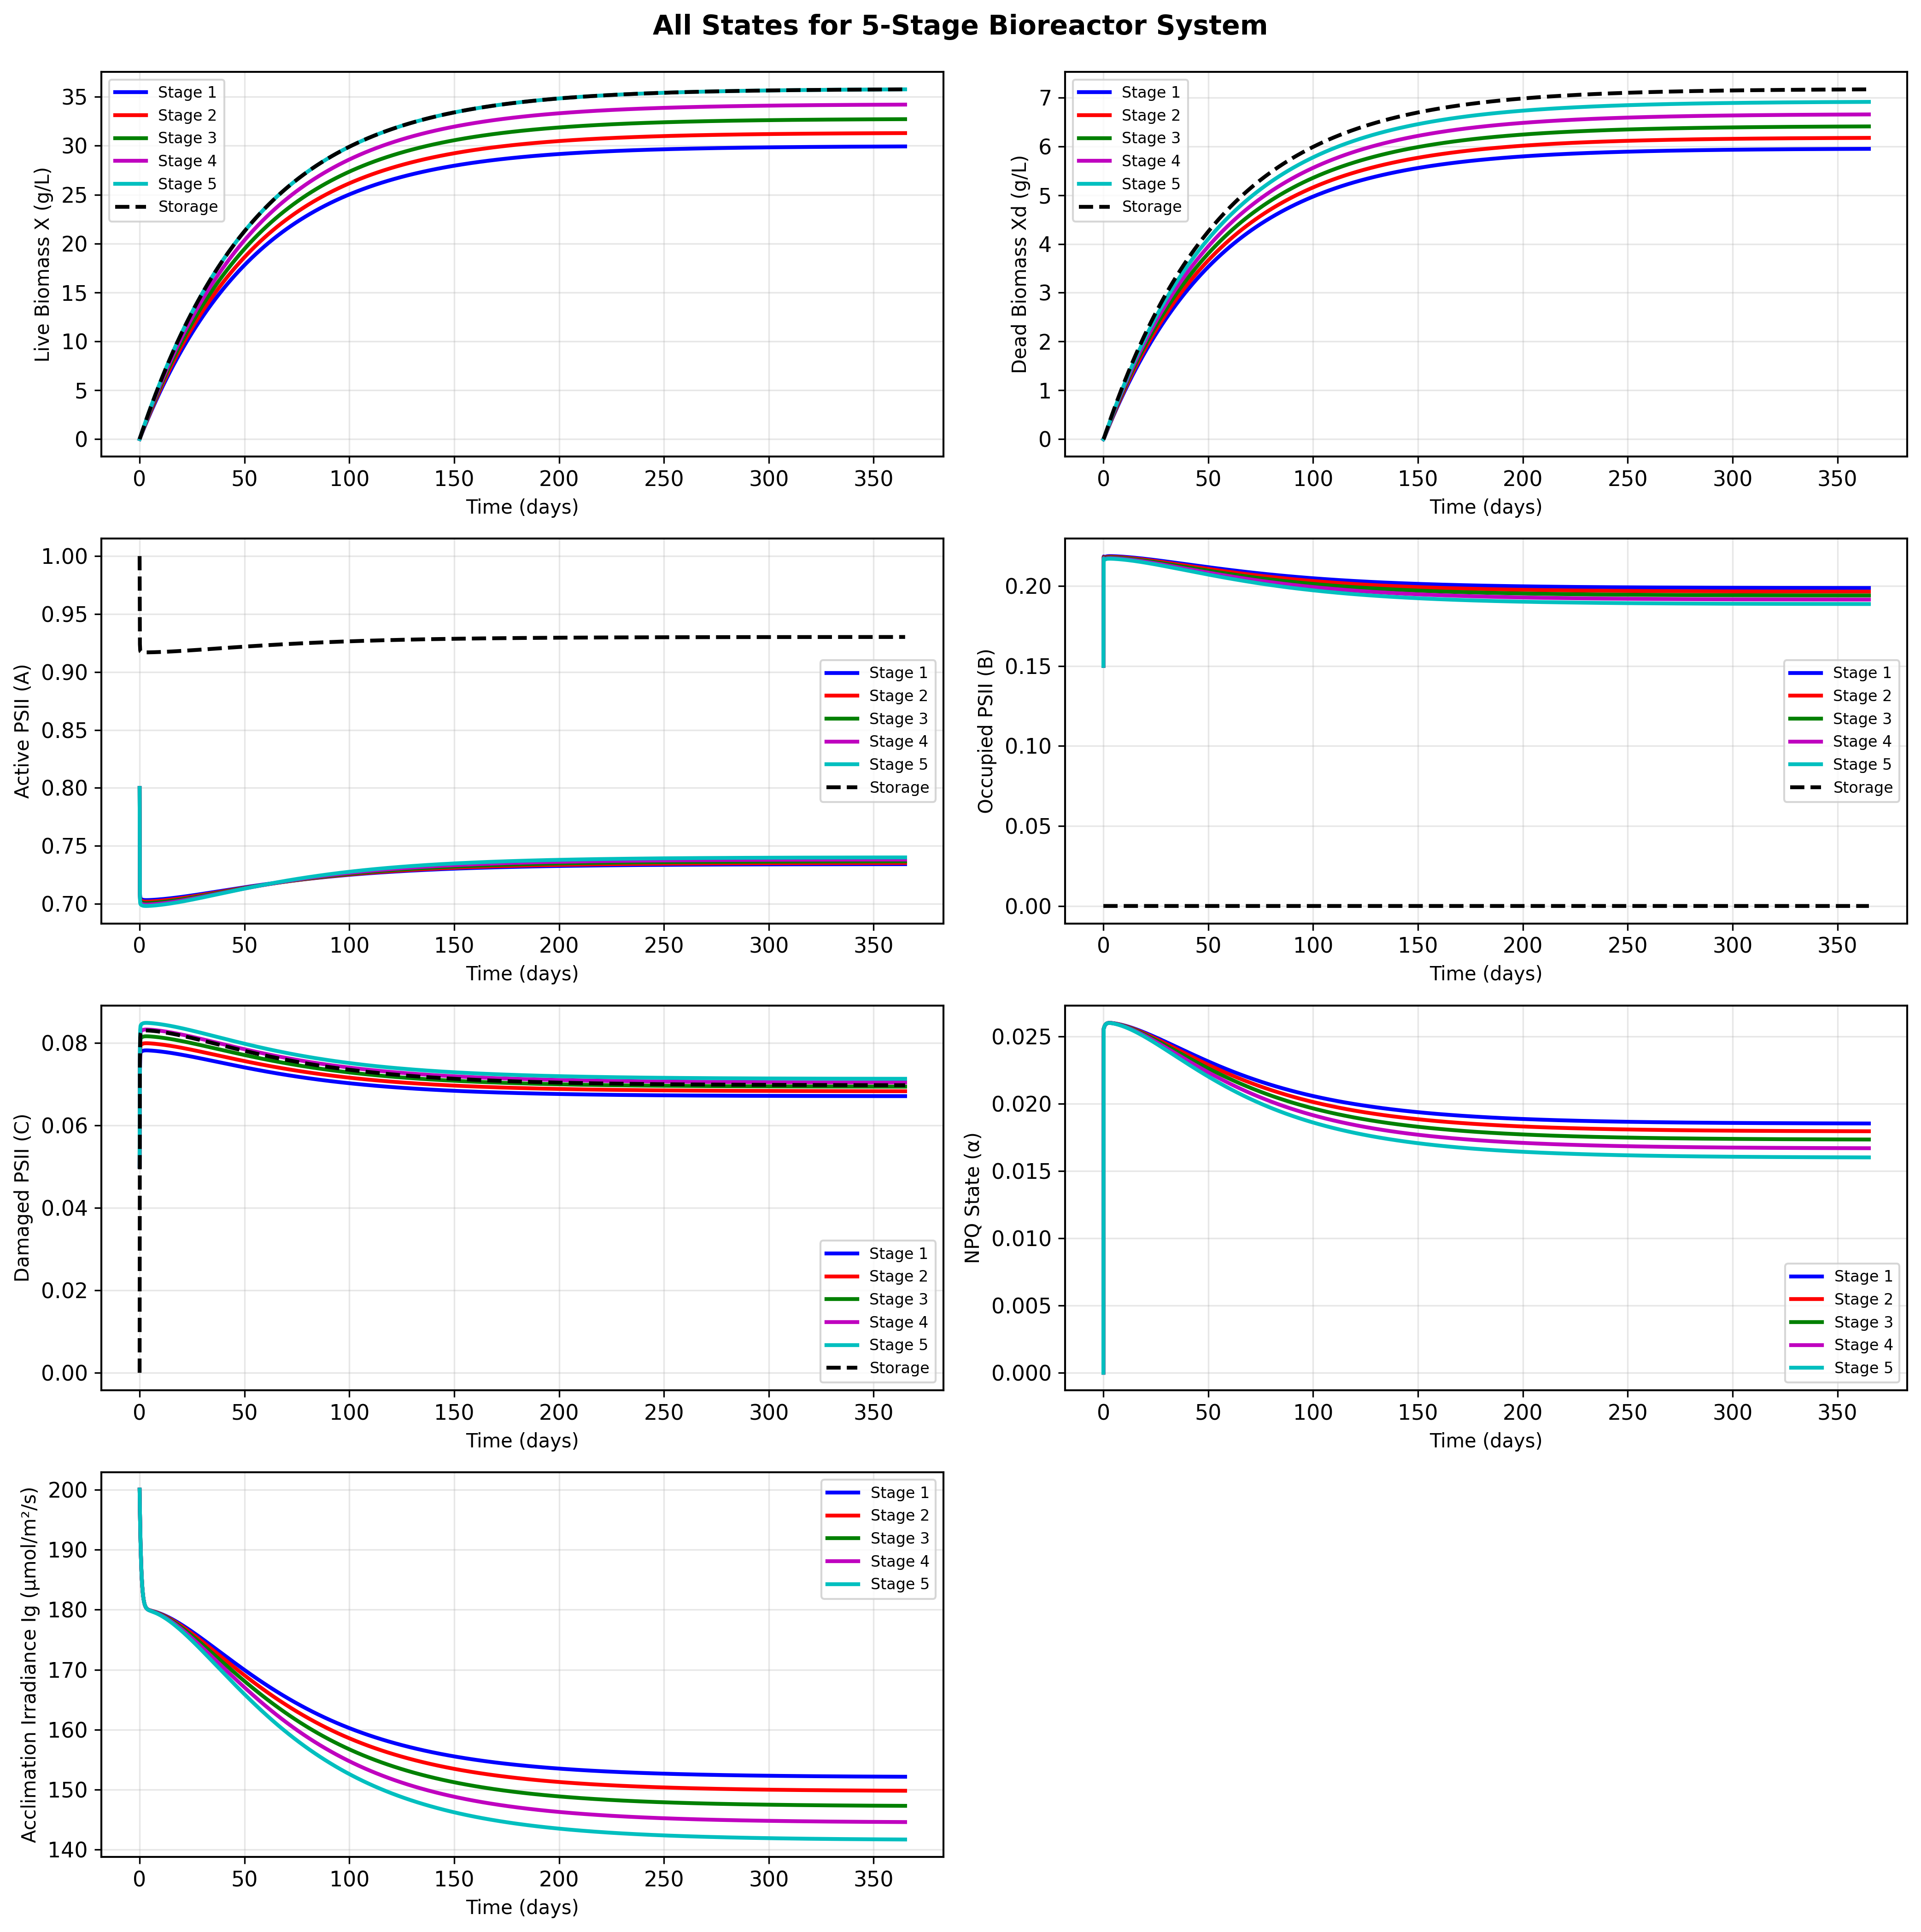

In [440]:
time = Pred_Exp[:, 0]/86400  # Time in days

X_stages = []
A_stages = []
B_stages = []
C_stages = []
alpha_stages = []
Ig_stages = []
Xd_stages = []

for i in range(5):  # 5 stages
    base_col = 1 + i * 7
    X_stages.append(Pred_Exp[:, base_col]) # Convert to per day
    A_stages.append(Pred_Exp[:, base_col + 1])
    B_stages.append(Pred_Exp[:, base_col + 2])
    C_stages.append(Pred_Exp[:, base_col + 3])
    alpha_stages.append(Pred_Exp[:, base_col + 4])
    Ig_stages.append(Pred_Exp[:, base_col + 5])
    Xd_stages.append(Pred_Exp[:, base_col + 6]) # Convert to per day

# Storage tank: columns after all stages (8*7 + 1 = 57)
storage_base = 1 + 5 * 7
X_s = Pred_Exp[:, storage_base]
X_ds = Pred_Exp[:, storage_base + 1]
A_s = Pred_Exp[:, storage_base + 2]
B_s = Pred_Exp[:, storage_base + 3]
C_s = Pred_Exp[:, storage_base + 4]

# Colors for each stage
colors = ['b', 'r', 'g', 'm', 'c']
labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# Create comprehensive plot with all states
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
# Print final values for all stages
print(f"\n{'='*70}")
print(f"Final Values at t = {time[-1]:.1f} days:")
print(f"{'='*70}")
for i in range(2):
    print(f"\nStage {i+1}:")
    print(f"  X  (live biomass)  = {X_stages[i][-1]:.6f} g/L")
    print(f"  Xd (dead biomass)  = {Xd_stages[i][-1]:.6f} g/L")
    print(f"  A  (active PSII)   = {A_stages[i][-1]:.4f}")
    print(f"  B  (occupied PSII) = {B_stages[i][-1]:.4f}")
    print(f"  C  (damaged PSII)  = {C_stages[i][-1]:.4f}")

print(f"\nStorage Tank:")
print(f"  X_s  (live biomass)   = {X_s[-1]:.6f} g/L")
print(f"  X_ds (dead biomass)   = {X_ds[-1]:.6f} g/L")
print(f"{'='*70}\n")
# Row 1: Biomass concentrations (X and Xd)
for i in range(5):
    axes[0, 0].plot(time, X_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[0, 0].plot(time, X_s, 'k--', linewidth=2, label='Storage')
axes[0, 0].set_xlabel('Time (days)', fontsize=10)
axes[0, 0].set_ylabel('Live Biomass X (g/L)', fontsize=10)
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

for i in range(5):
    axes[0, 1].plot(time, Xd_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[0, 1].plot(time, X_ds, 'k--', linewidth=2, label='Storage')
axes[0, 1].set_xlabel('Time (days)', fontsize=10)
axes[0, 1].set_ylabel('Dead Biomass Xd (g/L)', fontsize=10)
axes[0, 1].legend(fontsize=8, loc='best')
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Photosystem states (A, B)
for i in range(5):
    axes[1, 0].plot(time, A_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[1, 0].plot(time, A_s, 'k--', linewidth=2, label='Storage')
axes[1, 0].set_xlabel('Time (days)', fontsize=10)
axes[1, 0].set_ylabel('Active PSII (A)', fontsize=10)
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

for i in range(5):
    axes[1, 1].plot(time, B_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[1, 1].plot(time, B_s, 'k--', linewidth=2, label='Storage')
axes[1, 1].set_xlabel('Time (days)', fontsize=10)
axes[1, 1].set_ylabel('Occupied PSII (B)', fontsize=10)
axes[1, 1].legend(fontsize=8, loc='best')
axes[1, 1].grid(True, alpha=0.3)

# Row 3: Damaged PSII (C) and NPQ (alpha)
for i in range(5):
    axes[2, 0].plot(time, C_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[2, 0].plot(time, C_s, 'k--', linewidth=2, label='Storage')
axes[2, 0].set_xlabel('Time (days)', fontsize=10)
axes[2, 0].set_ylabel('Damaged PSII (C)', fontsize=10)
axes[2, 0].legend(fontsize=8, loc='best')
axes[2, 0].grid(True, alpha=0.3)

for i in range(5):
    axes[2, 1].plot(time, alpha_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[2, 1].set_xlabel('Time (days)', fontsize=10)
axes[2, 1].set_ylabel('NPQ State (α)', fontsize=10)
axes[2, 1].legend(fontsize=8, loc='best')
axes[2, 1].grid(True, alpha=0.3)

# Row 4: Acclimation irradiance
for i in range(5):
    axes[3, 0].plot(time, Ig_stages[i], f'{colors[i]}-', linewidth=2, label=labels[i])
axes[3, 0].set_xlabel('Time (days)', fontsize=10)
axes[3, 0].set_ylabel('Acclimation Irradiance Ig (μmol/m²/s)', fontsize=10)
axes[3, 0].legend(fontsize=8, loc='best')
axes[3, 0].grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[3, 1])

plt.suptitle('All States for 5-Stage Bioreactor System', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



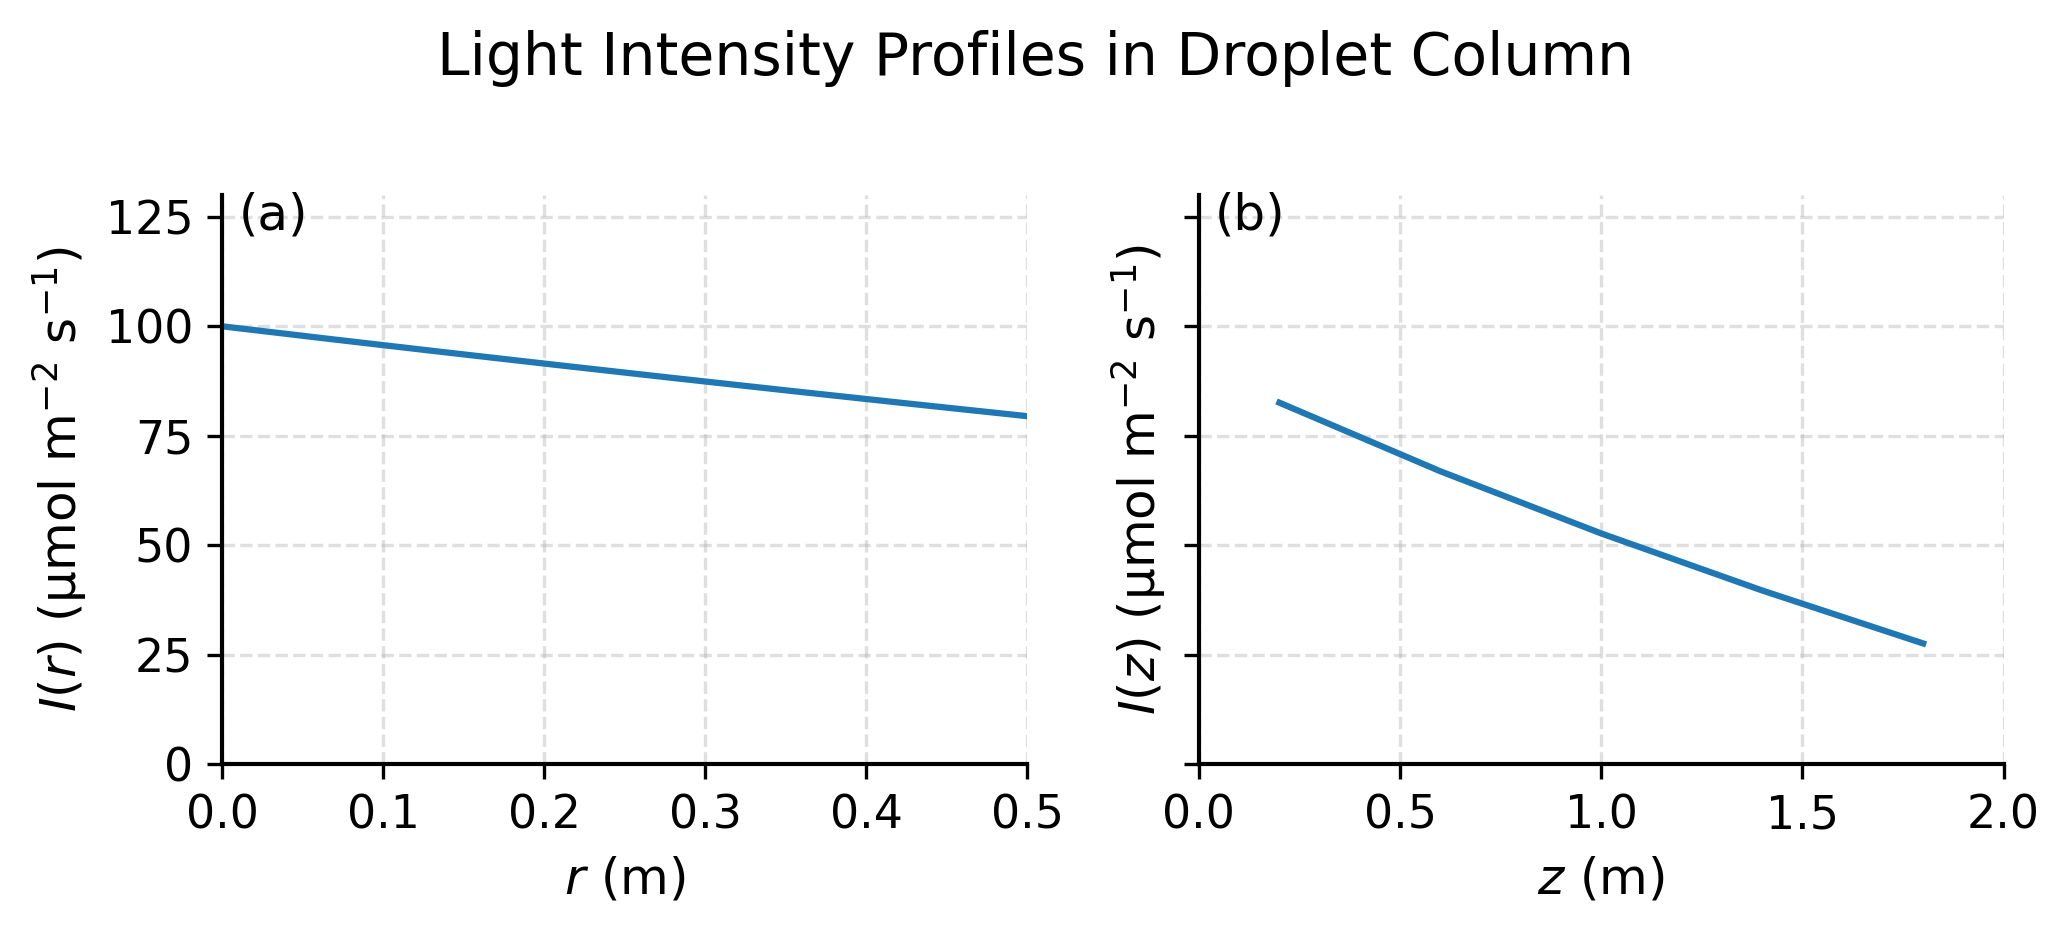

In [441]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],   # Matplotlib default
    "mathtext.fontset": "dejavusans",     # Use DejaVu Sans for math
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 300
})

I0 = 100
R_col = 0.5
K = 200
dr = R_col / K
sqrt3 = np.sqrt(3.0)

z = 2.0
N_LAYERS = 5
dz_layer = z / N_LAYERS

F_plus  = I0
F_minus = 0.0

theta_initial = np.radians(10)

r_vals = []
Ir_profile = []
z_vals = []
Iz_profile = []

C_ext, C_sca = mie_coeff(d_drop, wavelength_test, m_rel_test)
beta_layer  = float(np.real(C_ext * n0 * R_col))   # Extinction coefficient
sigma_layer = float(np.real(C_sca * n0 * R_col))   # Scattering coefficient

# --- vertical profile (z) ---
for j in range(N_LAYERS):
    z_layer = (j + 0.5) * dz_layer
    z_vals.append(z_layer)

    dF_plus  = sqrt3 * dz_layer * (-beta_layer*F_plus + sigma_layer*(f*F_plus + b*F_minus))
    dF_minus = sqrt3 * dz_layer * ( beta_layer*F_minus - sigma_layer*(f*F_minus + b*F_plus))
    F_plus  += dF_plus
    F_minus += dF_minus

    Iz_layer = F_plus + F_minus
    Iz_profile.append(Iz_layer)

# --- radial profile (r) ---
F_plus  = I0
F_minus = 0.0

for k in range(K + 1):
    r_k = k * dr
    Ir_k = F_plus + F_minus
    r_vals.append(r_k)
    Ir_profile.append(Ir_k)

    if k < K:
        dF_plus  = sqrt3 * dr * (-beta_layer*F_plus + sigma_layer*(f*F_plus + b*F_minus))
        dF_minus = sqrt3 * dr * ( beta_layer*F_minus - sigma_layer*(f*F_minus + b*F_plus))
        F_plus  += dF_plus
        F_minus += dF_minus

r_vals     = np.array(r_vals)
Ir_profile = np.array(Ir_profile)
z_vals     = np.array(z_vals)
Iz_profile = np.array(Iz_profile)

# ---------- PLOTTING IN "PAPER" STYLE ----------
fig, axes = plt.subplots(1, 2, figsize=(7, 3.0), sharey=True)

# (a) Radial profile
ax = axes[0]
ax.plot(r_vals, Ir_profile, linewidth=1.5)
ax.set_xlabel(r'$r$ (m)')
ax.set_ylabel(r'$I(r)$ (µmol m$^{-2}$ s$^{-1}$)')
ax.set_xlim(0, R_col)
ax.set_ylim(0, 1.3*I0)
ax.grid(True, linestyle='--', alpha=0.4)
ax.text(0.02, 0.94, '(a)', transform=ax.transAxes, fontsize=12)

# (b) Vertical profile
ax2 = axes[1]
ax2.plot(z_vals, Iz_profile, linewidth=1.5)
ax2.set_xlabel(r'$z$ (m)')
ax2.set_ylabel(r'$I(z)$ (µmol m$^{-2}$ s$^{-1}$)')
ax2.set_xlim(0, z)
ax2.set_ylim(0, 1.3*I0)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.text(0.02, 0.94, '(b)', transform=ax2.transAxes, fontsize=12)

# Clean up spines
for a in axes:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.suptitle('Light Intensity Profiles in Droplet Column', fontsize=14, y=1.02, ha='center')
plt.tight_layout()
plt.show()


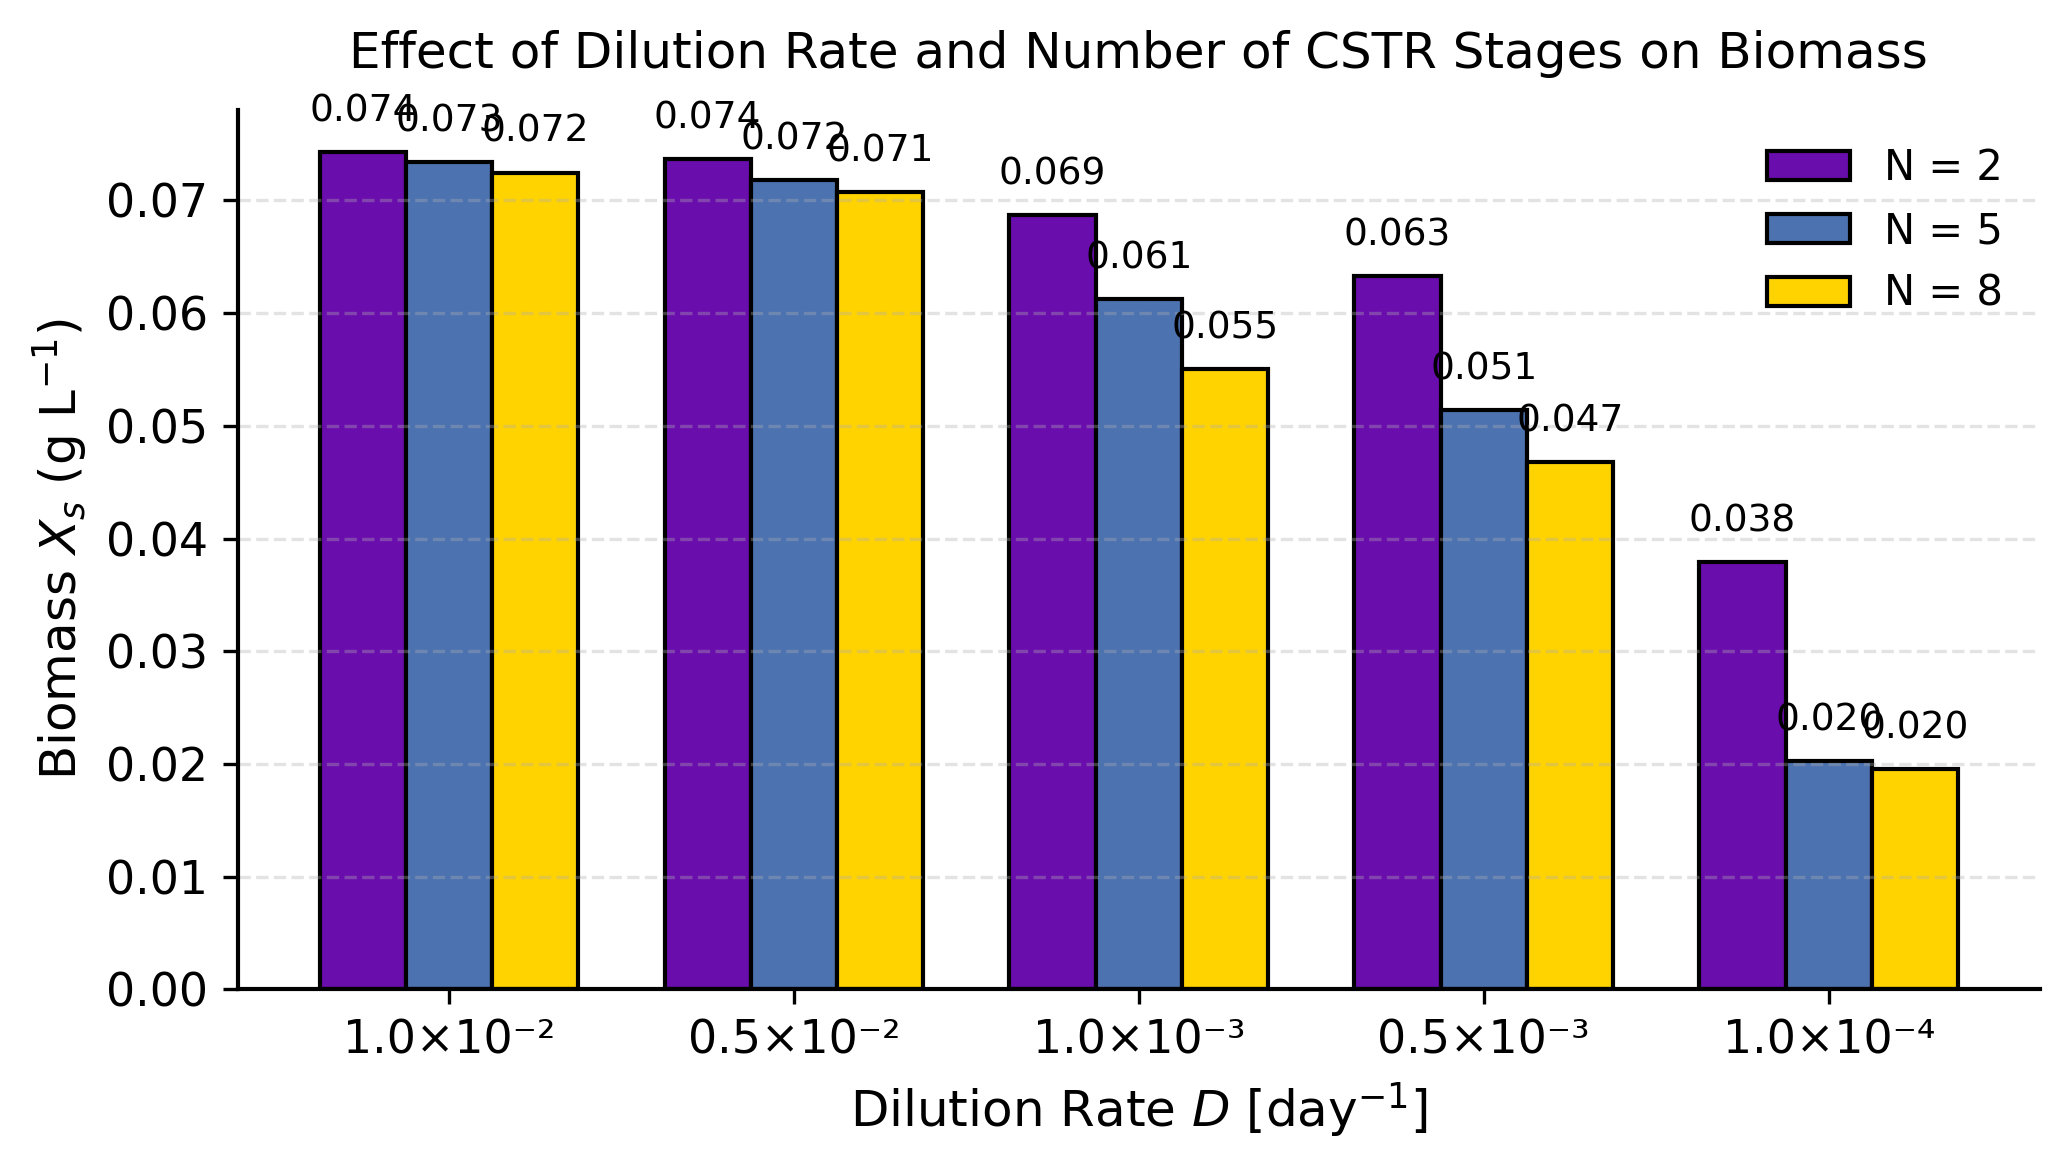

In [442]:


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 300
})

# ---------- Data ----------
D_vals = ['1.0×10⁻²', '0.5×10⁻²', '1.0×10⁻³', '0.5×10⁻³', '1.0×10⁻⁴']

# Biomass for each N = [2-stage, 5-stage, 8-stage]
X_N2 = np.array([0.074321, 0.073654, 0.068684, 0.063274, 0.037933])   # N = 2
X_N5 = np.array([0.073381, 0.071825 , 0.061218,  0.051361, 0.020280])   # N = 5
X_N8 = np.array([0.072463, 0.070693, 0.055054, 0.046790, 0.019554])   # N = 8

X_all = [X_N2, X_N5, X_N8]
labels_N = ['N = 2', 'N = 5', 'N = 8']

# x positions
x = np.arange(len(D_vals))

# width of each bar
width = 0.25

# colors (purple–green–yellow research palette)
colors = ['#6A0DAD', '#4C72B0', '#FFD300']

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4))

bars1 = ax.bar(x - width, X_N2, width, color=colors[0], edgecolor='black', label='N = 2')
bars2 = ax.bar(x,         X_N5, width, color=colors[1], edgecolor='black', label='N = 5')
bars3 = ax.bar(x + width, X_N8, width, color=colors[2], edgecolor='black', label='N = 8')

# labels
ax.set_ylabel(r'Biomass $X_s$ (g L$^{-1}$)')
ax.set_xlabel(r'Dilution Rate $D$ [day$^{-1}$]')
ax.set_title(r'Effect of Dilution Rate and Number of CSTR Stages on Biomass', pad=10)

# ticks
ax.set_xticks(x)
ax.set_xticklabels(D_vals)

# grid
ax.grid(axis='y', linestyle='--', alpha=0.35)

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend
ax.legend(frameon=False)

# add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f"{height:.3f}",
            ha='center', va='bottom', fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()
